In [2]:
import zipfile, os

zip_path = 'archive.zip'  # adjust if your zip is elsewhere
if not os.path.exists('ml-latest-small'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print("Extracted ml-latest-small/")
else:
    print("Already extracted.")



import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import time, warnings, random
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. LOAD DATA
# ──────────────────────────────────────────────
print("=" * 65)
print("  ITEM-BASED COLLABORATIVE FILTERING — MovieLens Small")
print("=" * 65)

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies  = pd.read_csv('ml-latest-small/movies.csv')

print(f"\nRatings       : {ratings.shape[0]:,}")
print(f"Users         : {ratings['userId'].nunique()}")
print(f"Movies        : {ratings['movieId'].nunique()}")
sparsity = 1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())
print(f"Sparsity      : {sparsity:.2%}")

# ──────────────────────────────────────────────
# 2. TRAIN / TEST SPLIT
# ──────────────────────────────────────────────
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)
test_sample = test_data.sample(n=2000, random_state=42).reset_index(drop=True)
print(f"\nTrain         : {len(train_data):,}")
print(f"Test (sample) : {len(test_sample):,}")

# ──────────────────────────────────────────────
# 3. USER-ITEM MATRIX
# ──────────────────────────────────────────────
user_item = train_data.pivot_table(index='userId', columns='movieId', values='rating')
ui_filled = user_item.fillna(0)
movie_ids = user_item.columns
user_ids  = user_item.index
print(f"Matrix        : {user_item.shape}")

ui_np        = user_item.values
ui_filled_np = ui_filled.values
movie_id_list = movie_ids.tolist()
user_id_list  = user_ids.tolist()
movie_to_idx  = {m: i for i, m in enumerate(movie_id_list)}
user_to_idx   = {u: i for i, u in enumerate(user_id_list)}

# ──────────────────────────────────────────────
# 4. SIMILARITY MATRICES
# ──────────────────────────────────────────────
print("\nComputing similarities...")

t0 = time.time()
item_vecs = ui_filled_np.T
cos_sim   = cosine_similarity(item_vecs)
print(f"  Cosine          : {time.time()-t0:.1f}s")

t0 = time.time()
user_means = np.nanmean(ui_np, axis=1, keepdims=True)
adjusted   = np.where(np.isnan(ui_np), 0, ui_np - user_means)
adj_cos_sim = cosine_similarity(adjusted.T)
print(f"  Adjusted Cosine : {time.time()-t0:.1f}s")

t0 = time.time()
item_means = ui_filled_np.mean(axis=0, keepdims=True)
centered   = ui_filled_np - item_means
pearson_sim = cosine_similarity(centered.T)
print(f"  Pearson         : {time.time()-t0:.1f}s")

sims = {
    'Cosine':          cos_sim,
    'Adjusted Cosine': adj_cos_sim,
    'Pearson':         pearson_sim,
}

# ──────────────────────────────────────────────
# 5. EVALUATE EACH METHOD
# ──────────────────────────────────────────────
K = 30

def evaluate(sim_matrix, label):
    print(f"\n{'─'*50}")
    print(f"  Evaluating: {label}")
    print(f"{'─'*50}")
    t0 = time.time()
    preds, actuals = [], []
    skipped = 0

    for _, row in test_sample.iterrows():
        uid, mid, actual = int(row['userId']), int(row['movieId']), row['rating']
        if uid not in user_to_idx or mid not in movie_to_idx:
            skipped += 1
            continue

        u_idx = user_to_idx[uid]
        m_idx = movie_to_idx[mid]

        rated_mask = ~np.isnan(ui_np[u_idx])
        rated_indices = np.where(rated_mask)[0]
        if len(rated_indices) == 0:
            skipped += 1
            continue

        sim_vals  = sim_matrix[m_idx, rated_indices]
        rat_vals  = ui_np[u_idx, rated_indices]

        if len(sim_vals) > K:
            top_k = np.argpartition(np.abs(sim_vals), -K)[-K:]
        else:
            top_k = np.arange(len(sim_vals))

        s = sim_vals[top_k]
        r = rat_vals[top_k]
        denom = np.abs(s).sum()
        if denom == 0:
            skipped += 1
            continue

        pred = np.clip((s * r).sum() / denom, 0.5, 5.0)
        preds.append(pred)
        actuals.append(actual)

    elapsed = time.time() - t0
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    cov  = len(preds) / len(test_sample) * 100

    print(f"  RMSE        : {rmse:.4f}")
    print(f"  MAE         : {mae:.4f}")
    print(f"  Coverage    : {cov:.1f}%  ({len(preds)}/{len(test_sample)})")
    print(f"  Time        : {elapsed:.1f}s")
    return {'RMSE': rmse, 'MAE': mae, 'Coverage (%)': round(cov, 1), 'Time (s)': round(elapsed, 1)}

results = {}
for name, sim_mat in sims.items():
    results[name] = evaluate(sim_mat, name)

# ──────────────────────────────────────────────
# 6. COMPARISON TABLE
# ──────────────────────────────────────────────
print("\n" + "=" * 65)
print("  COMPARISON SUMMARY")
print("=" * 65)
comp_df = pd.DataFrame(results).T
print(comp_df.to_string())

best_method = comp_df['RMSE'].idxmin()
print(f"\n  ★ Best by RMSE: {best_method} ({comp_df.loc[best_method, 'RMSE']:.4f})")

# ──────────────────────────────────────────────
# 7. BAR CHART COMPARISON
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = list(results.keys())
colors  = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric, ylabel in zip(axes,
                               ['RMSE', 'MAE', 'Coverage (%)'],
                               ['RMSE', 'MAE', 'Coverage (%)']):
    vals = [results[m][metric] for m in methods]
    bars = ax.bar(methods, vals, color=colors, edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        fmt = f'{v:.4f}' if 'Coverage' not in metric else f'{v:.1f}%'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=10)
    tag = ' (lower is better)' if 'Coverage' not in metric else ''
    ax.set_title(f'{metric}{tag}', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)

plt.suptitle('Item-Based Collaborative Filtering — Metric Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
print("\nSaved: comparison_chart.png")

# ──────────────────────────────────────────────
# 8. SIMILARITY HEATMAP
# ──────────────────────────────────────────────
best_sim = sims[best_method]
top10_mids = train_data['movieId'].value_counts().head(10).index.tolist()
top10_idx  = [movie_to_idx[m] for m in top10_mids if m in movie_to_idx]
top10_mids_f = [movie_id_list[i] for i in top10_idx]

titles = []
for mid in top10_mids_f:
    t = movies.loc[movies['movieId'] == mid, 'title'].values
    titles.append((t[0][:32] if len(t) > 0 else str(mid)))

sub = best_sim[np.ix_(top10_idx, top10_idx)]

fig2, ax2 = plt.subplots(figsize=(10, 8))
im = ax2.imshow(sub, cmap='YlOrRd', vmin=-0.2, vmax=1)
ax2.set_xticks(range(len(titles)))
ax2.set_yticks(range(len(titles)))
ax2.set_xticklabels(titles, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(titles, fontsize=8)
for i in range(len(titles)):
    for j in range(len(titles)):
        ax2.text(j, i, f'{sub[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_title(f'{best_method} Similarity — Top 10 Popular Movies',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
print("Saved: similarity_heatmap.png")

# ──────────────────────────────────────────────
# 9. TOP-10 RECOMMENDATIONS (User 1)
# ──────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  TOP-10 RECOMMENDATIONS FOR USER 1  ({best_method})")
print("=" * 65)

u_idx = user_to_idx[1]
rated_mask = ~np.isnan(ui_np[u_idx])
rated_set  = set(np.where(rated_mask)[0])
unrated_idx = [i for i in range(len(movie_id_list)) if i not in rated_set]
rated_indices = np.where(rated_mask)[0]

random.seed(42)
candidates = random.sample(unrated_idx, min(500, len(unrated_idx)))

scores = []
for m_idx in candidates:
    sv  = best_sim[m_idx, rated_indices]
    rv  = ui_np[u_idx, rated_indices]
    if len(sv) > K:
        tk = np.argpartition(np.abs(sv), -K)[-K:]
    else:
        tk = np.arange(len(sv))
    s = sv[tk]; r = rv[tk]
    d = np.abs(s).sum()
    if d > 0:
        scores.append((movie_id_list[m_idx], np.clip((s*r).sum()/d, 0.5, 5.0)))

scores.sort(key=lambda x: x[1], reverse=True)
print(f"\n{'Rank':<6}{'Movie':<55}{'Predicted':>10}")
print("-" * 71)
for rank, (mid, sc) in enumerate(scores[:10], 1):
    t = movies.loc[movies['movieId'] == mid, 'title'].values
    t = t[0] if len(t) > 0 else f"ID {mid}"
    print(f"{rank:<6}{t:<55}{sc:>10.3f}")

print("\n✓ Done.")


Extracted ml-latest-small/
  ITEM-BASED COLLABORATIVE FILTERING — MovieLens Small

Ratings       : 100,836
Users         : 610
Movies        : 9724
Sparsity      : 98.30%

Train         : 80,668
Test (sample) : 2,000
Matrix        : (610, 8983)

Computing similarities...
  Cosine          : 141.6s
  Adjusted Cosine : 116.8s
  Pearson         : 118.7s

──────────────────────────────────────────────────
  Evaluating: Cosine
──────────────────────────────────────────────────
  RMSE        : 0.8520
  MAE         : 0.6521
  Coverage    : 96.2%  (1924/2000)
  Time        : 1.2s

──────────────────────────────────────────────────
  Evaluating: Adjusted Cosine
──────────────────────────────────────────────────
  RMSE        : 2.3678
  MAE         : 2.0666
  Coverage    : 96.2%  (1924/2000)
  Time        : 1.0s

──────────────────────────────────────────────────
  Evaluating: Pearson
──────────────────────────────────────────────────
  RMSE        : 0.8644
  MAE         : 0.6632
  Coverage    :

In [6]:
import zipfile, os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import time, warnings, random
warnings.filterwarnings('ignore')
%matplotlib inline

zip_path = 'archive.zip'
if not os.path.exists('ml-latest-small'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies  = pd.read_csv('ml-latest-small/movies.csv')

print(f"Ratings       : {ratings.shape[0]:,}")
print(f"Users         : {ratings['userId'].nunique()}")
print(f"Movies        : {ratings['movieId'].nunique()}")
sparsity = 1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())
print(f"Sparsity      : {sparsity:.2%}")

Ratings       : 100,836
Users         : 610
Movies        : 9724
Sparsity      : 98.30%


In [7]:
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)
test_sample = test_data.sample(n=2000, random_state=42).reset_index(drop=True)
print(f"Train         : {len(train_data):,}")
print(f"Test (sample) : {len(test_sample):,}")

user_item = train_data.pivot_table(index='userId', columns='movieId', values='rating')
ui_filled = user_item.fillna(0)

ui_np        = user_item.values
ui_filled_np = ui_filled.values
movie_id_list = user_item.columns.tolist()
user_id_list  = user_item.index.tolist()
movie_to_idx  = {m: i for i, m in enumerate(movie_id_list)}
user_to_idx   = {u: i for i, u in enumerate(user_id_list)}

print(f"Matrix        : {user_item.shape}")

Train         : 80,668
Test (sample) : 2,000
Matrix        : (610, 8983)


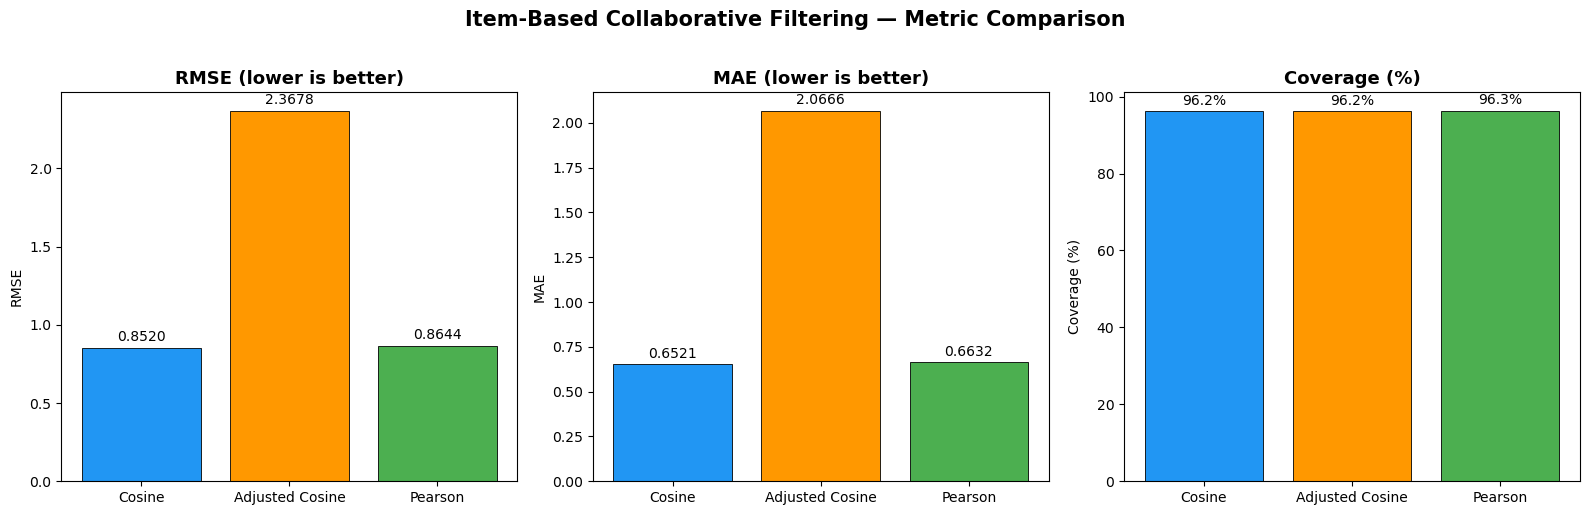

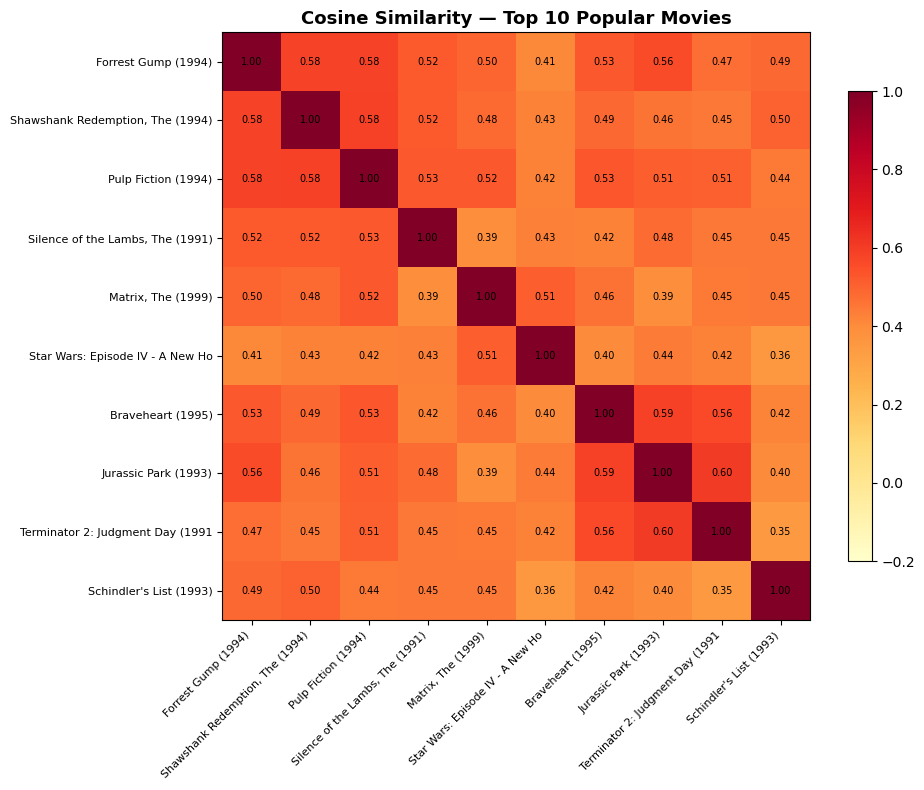

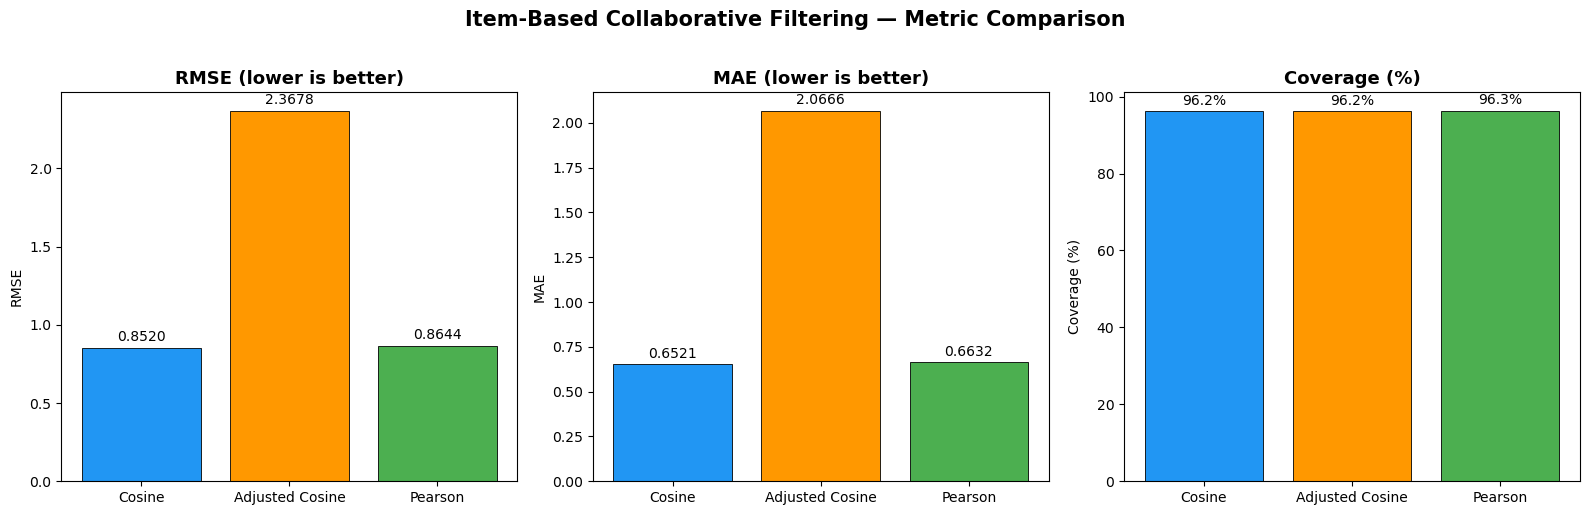

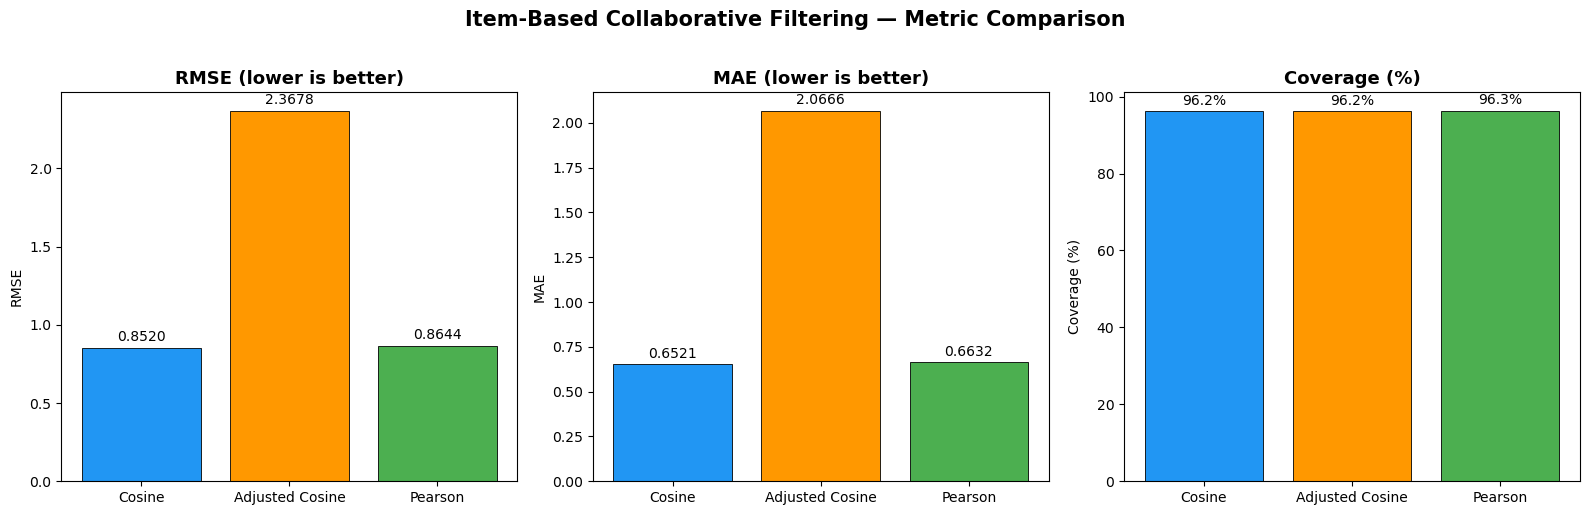

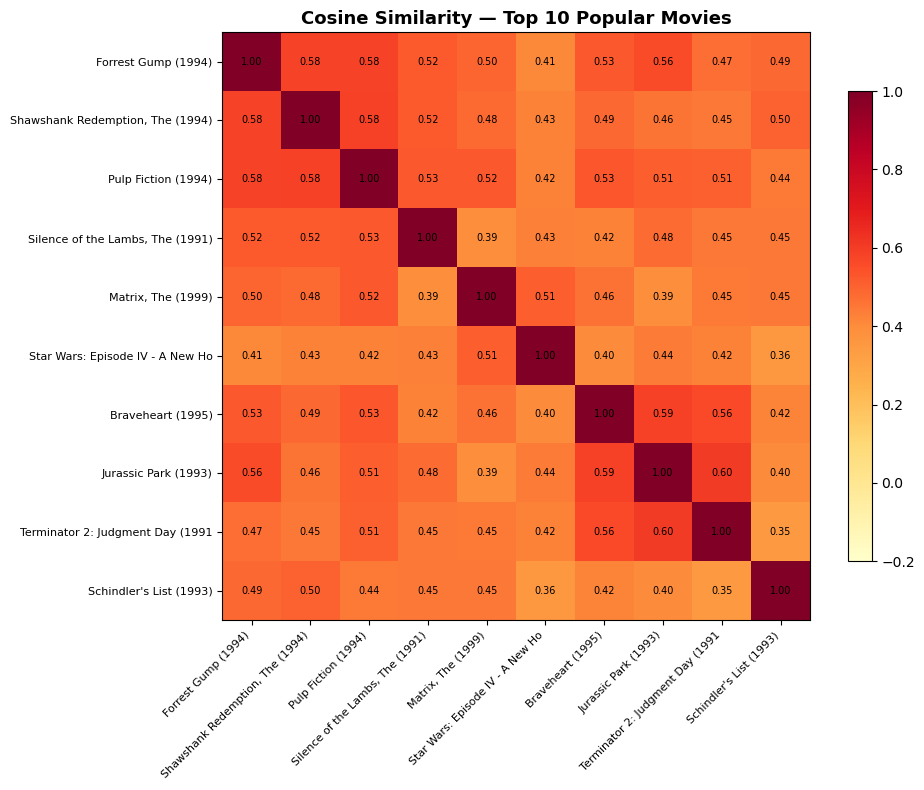

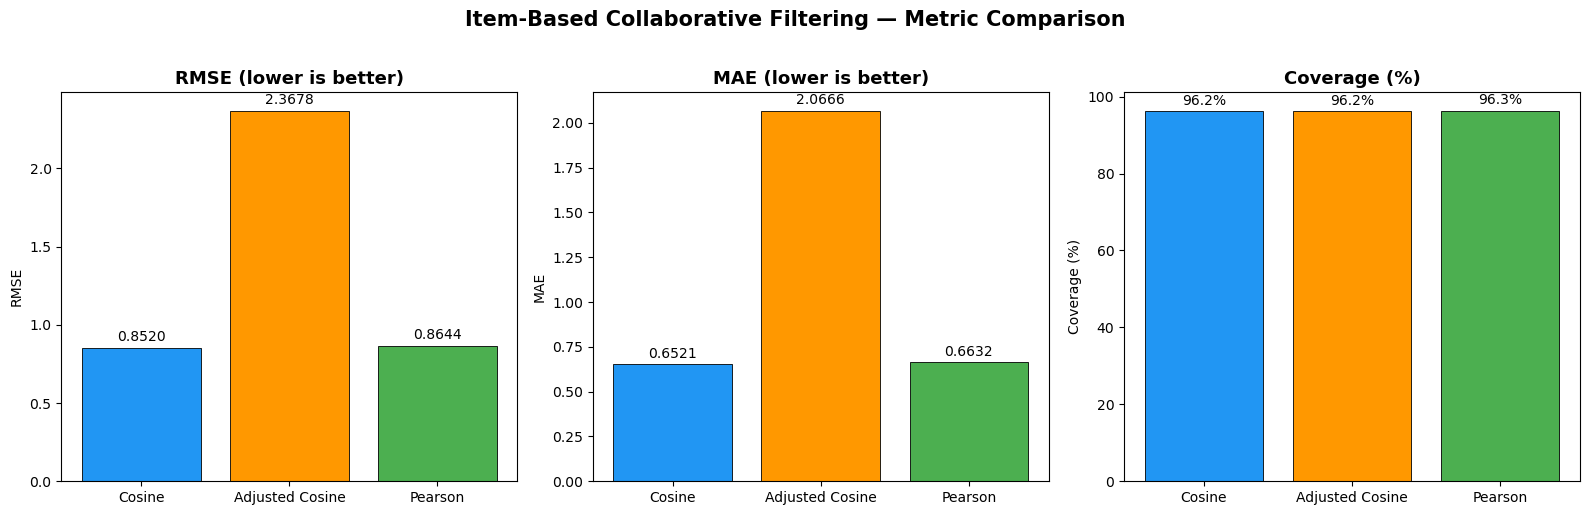

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = list(results.keys())
colors  = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'Coverage (%)']):
    vals = [results[m][metric] for m in methods]
    bars = ax.bar(methods, vals, color=colors, edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        fmt = f'{v:.4f}' if 'Coverage' not in metric else f'{v:.1f}%'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=10)
    tag = ' (lower is better)' if 'Coverage' not in metric else ''
    ax.set_title(f'{metric}{tag}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('Item-Based Collaborative Filtering — Metric Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()